# Notebook 10 — Regresión logística, clasificación multiclase y métricas

En este notebook estudiaremos cómo construir y evaluar modelos de clasificación con regresión logística.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- distinguir entre predicción de probabilidades y predicción de clases;
- ajustar una regresión logística binaria;
- interpretar la función logística;
- modificar el umbral de clasificación;
- construir una matriz de confusión;
- calcular accuracy, precision, recall y F1;
- analizar curvas ROC y Precision-Recall;
- ajustar una regresión logística multiclase;
- interpretar probabilidades producidas mediante Softmax;
- utilizar métricas macro, micro y weighted;
- evaluar clasificación multiclase mediante ROC-AUC One-vs-Rest;
- reconocer limitaciones de accuracy ante desbalance.

Usaremos datasets sintéticos generados con `scikit-learn`.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

RANDOM_STATE = 42

pd.options.display.float_format = "{:,.4f}".format


# Parte I. Clasificación binaria

## 2. Generación de un problema binario

Crearemos dos clases con cierto nivel de traslape.

La regresión logística modela la probabilidad:

\[
P(Y=1\mid X=x).
\]

Después convierte esa probabilidad en una clase mediante un umbral.

In [2]:
X_binary, y_binary = make_classification(
    n_samples=1_000,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_repeated=0,
    n_classes=2,
    weights=[0.72, 0.28],
    class_sep=1.1,
    flip_y=0.04,
    random_state=RANDOM_STATE,
)

feature_names_binary = [
    f"x_{index}"
    for index in range(1, X_binary.shape[1] + 1)
]

X_binary = pd.DataFrame(
    X_binary,
    columns=feature_names_binary,
)

y_binary = pd.Series(
    y_binary,
    name="clase",
)

print(y_binary.value_counts())
print()
print(y_binary.value_counts(normalize=True))


clase
0    713
1    287
Name: count, dtype: int64

clase
0   0.7130
1   0.2870
Name: proportion, dtype: float64


La clase positiva es menos frecuente. Esto permitirá observar por qué accuracy puede ser insuficiente.

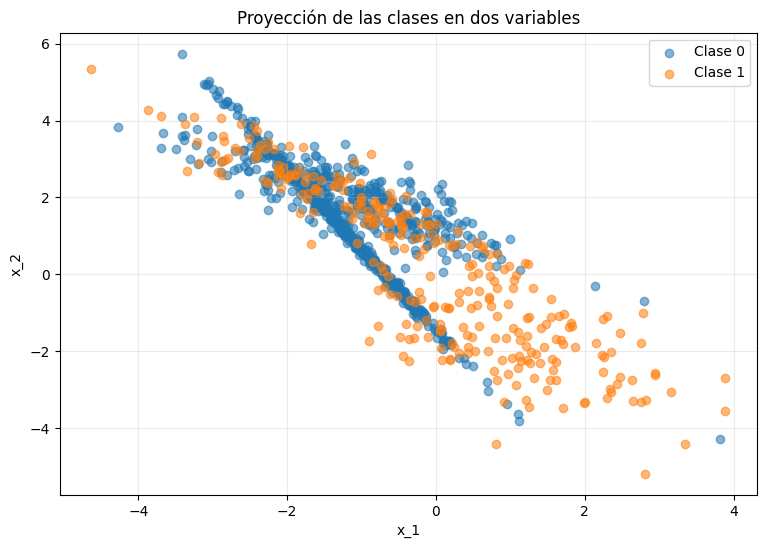

In [3]:
plt.figure(figsize=(9, 6))

for class_value in [0, 1]:
    mask = y_binary == class_value
    plt.scatter(
        X_binary.loc[mask, "x_1"],
        X_binary.loc[mask, "x_2"],
        alpha=0.55,
        label=f"Clase {class_value}",
    )

plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title("Proyección de las clases en dos variables")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 3. Split estratificado

In [4]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary,
    y_binary,
    test_size=0.25,
    stratify=y_binary,
    random_state=RANDOM_STATE,
)

print("Distribución en train")
print(y_train_bin.value_counts(normalize=True))
print()
print("Distribución en test")
print(y_test_bin.value_counts(normalize=True))


Distribución en train
clase
0   0.7133
1   0.2867
Name: proportion, dtype: float64

Distribución en test
clase
0   0.7120
1   0.2880
Name: proportion, dtype: float64


`stratify=y` conserva aproximadamente la proporción de clases en ambos conjuntos.

## 4. Baseline de clasificación

Usaremos un clasificador que siempre predice la clase más frecuente.

In [5]:
dummy = DummyClassifier(
    strategy="most_frequent",
)

dummy.fit(
    X_train_bin,
    y_train_bin,
)

dummy_predictions = dummy.predict(
    X_test_bin
)

print(
    "Accuracy baseline:",
    accuracy_score(
        y_test_bin,
        dummy_predictions,
    ),
)


Accuracy baseline: 0.712


Un accuracy aparentemente alto puede lograrse sin identificar ningún caso positivo.

## 5. Ajuste de regresión logística

Combinaremos escalamiento y regresión logística dentro de un `Pipeline`.

In [6]:
binary_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=2_000,
            random_state=RANDOM_STATE,
        ),
    ),
])

binary_model.fit(
    X_train_bin,
    y_train_bin,
)

binary_probabilities = binary_model.predict_proba(
    X_test_bin
)[:, 1]

binary_predictions = binary_model.predict(
    X_test_bin
)

binary_probabilities[:10]


array([0.21212814, 0.22191192, 0.74895921, 0.48998648, 0.08274901,
       0.10827281, 0.42449068, 0.22609091, 0.3614787 , 0.34851234])

`predict_proba` produce probabilidades para cada clase.

Para clasificación binaria:

- columna 0: \(P(Y=0\mid X)\);
- columna 1: \(P(Y=1\mid X)\).

Con el umbral predeterminado de 0.5:

\[
\widehat{y}=
\begin{cases}
1,&\widehat{p}\geq 0.5,\\
0,&\widehat{p}<0.5.
\end{cases}
\]

In [7]:
probability_table = pd.DataFrame({
    "Probabilidad clase 1": binary_probabilities[:15],
    "Clase predicha": binary_predictions[:15],
    "Clase real": y_test_bin.iloc[:15].to_numpy(),
})

probability_table


,Probabilidad clase 1,Clase predicha,Clase real
0,0.2121,0,1
1,0.2219,0,0
2,0.7490,1,1
3,0.4900,0,1
4,0.0827,0,0
5,0.1083,0,0
6,0.4245,0,1
7,0.2261,0,0
8,0.3615,0,0
9,0.3485,0,0


## 6. Matriz de confusión

In [8]:
binary_confusion = confusion_matrix(
    y_test_bin,
    binary_predictions,
)

binary_confusion


array([[169,   9],
       [ 53,  19]])

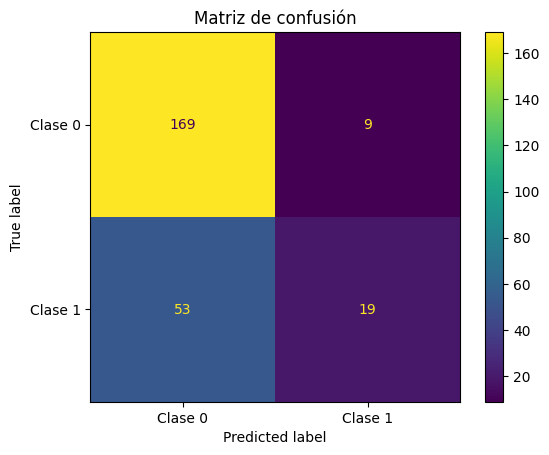

In [9]:
ConfusionMatrixDisplay(
    confusion_matrix=binary_confusion,
    display_labels=["Clase 0", "Clase 1"],
).plot()

plt.title("Matriz de confusión")
plt.show()


En clasificación binaria:

- **TP:** positivos correctamente identificados;
- **FP:** negativos clasificados como positivos;
- **TN:** negativos correctamente identificados;
- **FN:** positivos clasificados como negativos.

## 7. Métricas binarias

In [10]:
binary_metrics = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Log Loss",
    ],
    "Valor": [
        accuracy_score(
            y_test_bin,
            binary_predictions,
        ),
        precision_score(
            y_test_bin,
            binary_predictions,
        ),
        recall_score(
            y_test_bin,
            binary_predictions,
        ),
        f1_score(
            y_test_bin,
            binary_predictions,
        ),
        roc_auc_score(
            y_test_bin,
            binary_probabilities,
        ),
        log_loss(
            y_test_bin,
            binary_probabilities,
        ),
    ],
})

binary_metrics


,Métrica,Valor
0,Accuracy,0.7520
1,Precision,0.6786
2,Recall,0.2639
3,F1,0.3800
4,ROC-AUC,0.7598
5,Log Loss,0.5117


### Interpretación

- **Accuracy:** proporción total de aciertos.
- **Precision:** de los casos predichos como positivos, cuántos realmente eran positivos.
- **Recall:** de los positivos reales, cuántos fueron detectados.
- **F1:** media armónica de precision y recall.
- **ROC-AUC:** capacidad de ordenar positivos por encima de negativos.
- **Log Loss:** calidad de las probabilidades; penaliza probabilidades incorrectas con alta confianza.

In [11]:
print(
    classification_report(
        y_test_bin,
        binary_predictions,
        target_names=["Clase 0", "Clase 1"],
    )
)


              precision    recall  f1-score   support

     Clase 0       0.76      0.95      0.84       178
     Clase 1       0.68      0.26      0.38        72

    accuracy                           0.75       250
   macro avg       0.72      0.61      0.61       250
weighted avg       0.74      0.75      0.71       250



## 8. Efecto del umbral

El umbral de 0.5 no es una ley. Puede modificarse según el costo de falsos positivos y falsos negativos.

In [12]:
thresholds_to_compare = [
    0.20,
    0.35,
    0.50,
    0.65,
    0.80,
]

threshold_rows = []

for threshold in thresholds_to_compare:
    predictions_threshold = (
        binary_probabilities >= threshold
    ).astype(int)

    threshold_rows.append({
        "Umbral": threshold,
        "Accuracy": accuracy_score(
            y_test_bin,
            predictions_threshold,
        ),
        "Precision": precision_score(
            y_test_bin,
            predictions_threshold,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_test_bin,
            predictions_threshold,
            zero_division=0,
        ),
        "F1": f1_score(
            y_test_bin,
            predictions_threshold,
            zero_division=0,
        ),
        "Positivos predichos": predictions_threshold.sum(),
    })

threshold_table = pd.DataFrame(
    threshold_rows
)

threshold_table


,Umbral,Accuracy,Precision,Recall,F1,Positivos predichos
0,0.2000,0.5960,0.4027,0.8333,0.5430,149
1,0.3500,0.7200,0.5135,0.5278,0.5205,74
2,0.5000,0.7520,0.6786,0.2639,0.3800,28
3,0.6500,0.7400,0.7692,0.1389,0.2353,13
4,0.8000,0.7160,0.6667,0.0278,0.0533,3


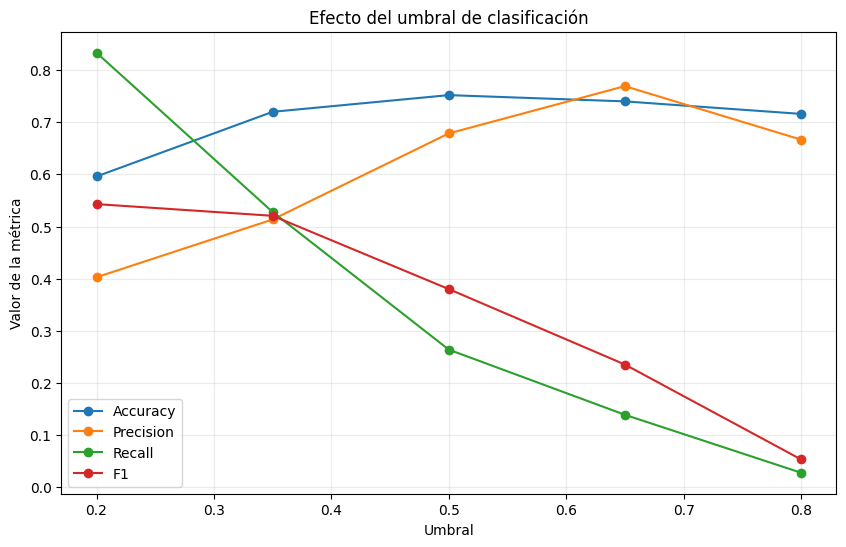

In [13]:
plt.figure(figsize=(10, 6))

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
]:
    plt.plot(
        threshold_table["Umbral"],
        threshold_table[metric],
        marker="o",
        label=metric,
    )

plt.xlabel("Umbral")
plt.ylabel("Valor de la métrica")
plt.title("Efecto del umbral de clasificación")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


Un umbral menor suele:

- aumentar recall;
- reducir precision;
- producir más positivos predichos.

La selección debe basarse en el objetivo operativo, no únicamente en una métrica genérica.

## 9. Curva ROC

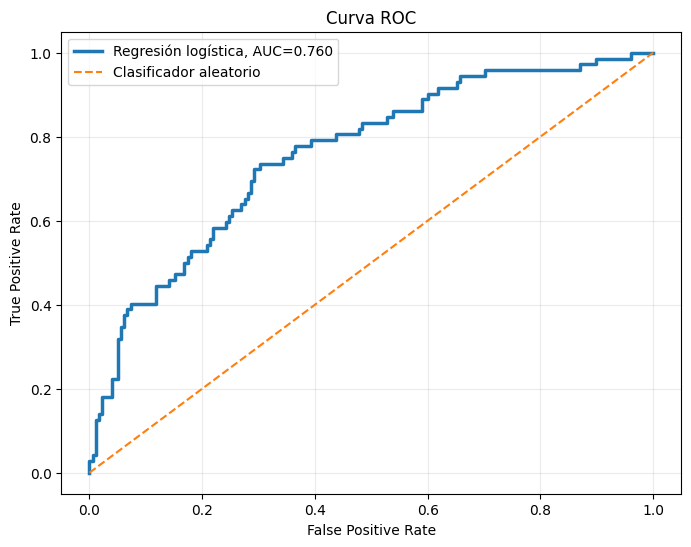

In [14]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test_bin,
    binary_probabilities,
)

binary_auc = roc_auc_score(
    y_test_bin,
    binary_probabilities,
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"Regresión logística, AUC={binary_auc:.3f}",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio",
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


La curva ROC representa el compromiso entre:

- sensibilidad o TPR;
- tasa de falsos positivos o FPR.

ROC-AUC evalúa el ranking de probabilidades a través de todos los umbrales.

## 10. Curva Precision-Recall

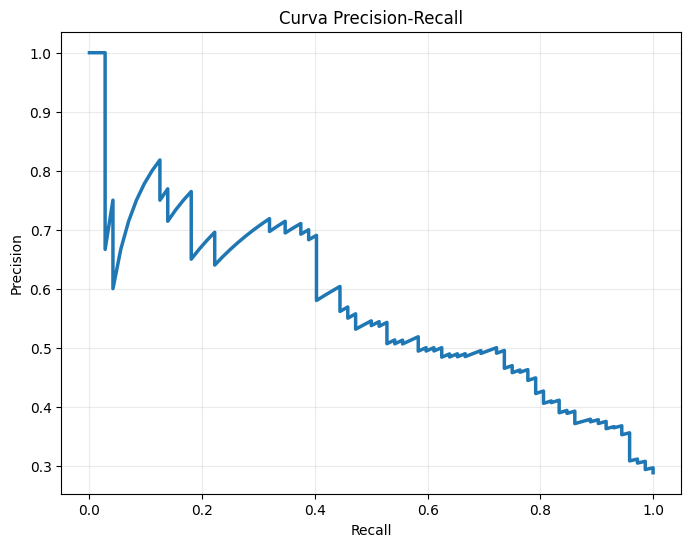

In [15]:
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test_bin,
        binary_probabilities,
    )
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_values,
    precision_values,
    linewidth=2.5,
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.grid(alpha=0.25)
plt.show()


La curva Precision-Recall suele ser especialmente informativa cuando la clase positiva es poco frecuente.

# Parte II. Clasificación multiclase

## 11. Generación de datos con tres clases

Crearemos un problema balanceado de tres clases.

In [16]:
X_multi, y_multi = make_classification(
    n_samples=1_200,
    n_features=8,
    n_informative=6,
    n_redundant=1,
    n_classes=3,
    n_clusters_per_class=1,
    weights=[0.45, 0.35, 0.20],
    class_sep=1.4,
    flip_y=0.03,
    random_state=RANDOM_STATE,
)

feature_names_multi = [
    f"x_{index}"
    for index in range(1, X_multi.shape[1] + 1)
]

X_multi = pd.DataFrame(
    X_multi,
    columns=feature_names_multi,
)

y_multi = pd.Series(
    y_multi,
    name="clase",
)

print(y_multi.value_counts())
print()
print(y_multi.value_counts(normalize=True))


clase
0    536
1    423
2    241
Name: count, dtype: int64

clase
0   0.4467
1   0.3525
2   0.2008
Name: proportion, dtype: float64


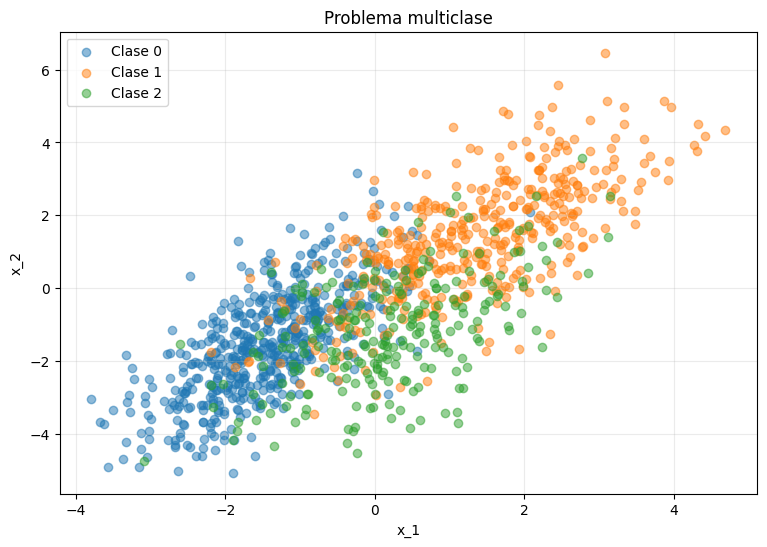

In [17]:
plt.figure(figsize=(9, 6))

for class_value in sorted(y_multi.unique()):
    mask = y_multi == class_value
    plt.scatter(
        X_multi.loc[mask, "x_1"],
        X_multi.loc[mask, "x_2"],
        alpha=0.5,
        label=f"Clase {class_value}",
    )

plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title("Problema multiclase")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 12. Split y ajuste multiclase

In [18]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = (
    train_test_split(
        X_multi,
        y_multi,
        test_size=0.25,
        stratify=y_multi,
        random_state=RANDOM_STATE,
    )
)

multiclass_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=3_000,
            random_state=RANDOM_STATE,
        ),
    ),
])

multiclass_model.fit(
    X_train_multi,
    y_train_multi,
)

multiclass_predictions = multiclass_model.predict(
    X_test_multi
)

multiclass_probabilities = multiclass_model.predict_proba(
    X_test_multi
)

multiclass_probabilities[:5]


array([[5.02579257e-04, 6.42717950e-03, 9.93070241e-01],
       [8.22147772e-01, 1.77234070e-01, 6.18158851e-04],
       [1.35019993e-01, 8.60850798e-01, 4.12920904e-03],
       [6.41073374e-02, 9.30514103e-01, 5.37855966e-03],
       [9.88493689e-04, 9.19750917e-02, 9.07036415e-01]])

En clasificación multiclase, el modelo produce una probabilidad por clase.

Las probabilidades de una observación suman uno.

La clase predicha es la de mayor probabilidad.

In [19]:
probability_sums = multiclass_probabilities.sum(axis=1)

print(
    "Mínimo de suma de probabilidades:",
    probability_sums.min(),
)
print(
    "Máximo de suma de probabilidades:",
    probability_sums.max(),
)


Mínimo de suma de probabilidades: 0.9999999999999998
Máximo de suma de probabilidades: 1.0000000000000002


In [20]:
multiclass_probability_table = pd.DataFrame(
    multiclass_probabilities[:10],
    columns=[
        f"P(clase={class_value})"
        for class_value in multiclass_model.classes_
    ],
)

multiclass_probability_table["Clase predicha"] = (
    multiclass_predictions[:10]
)

multiclass_probability_table["Clase real"] = (
    y_test_multi.iloc[:10].to_numpy()
)

multiclass_probability_table


,P(clase=0),P(clase=1),P(clase=2),Clase predicha,Clase real
0,0.0005,0.0064,0.9931,2,2
1,0.8221,0.1772,0.0006,0,0
2,0.1350,0.8609,0.0041,1,1
3,0.0641,0.9305,0.0054,1,1
4,0.0010,0.0920,0.9070,2,2
5,0.0093,0.9409,0.0498,1,1
6,0.0006,0.0570,0.9424,2,2
7,0.9729,0.0012,0.0259,0,0
8,0.9928,0.0055,0.0017,0,0
9,0.5863,0.4136,0.0001,0,0


## 13. Softmax

En un clasificador lineal multiclase se calcula un score por clase:

\[
z_k=\beta_{0k}+x^\top\beta_k.
\]

Softmax transforma esos scores en probabilidades:

\[
P(Y=k\mid x)
=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}.
\]

La clase con mayor probabilidad se convierte en la predicción.

## 14. Matriz de confusión multiclase

In [21]:
multiclass_confusion = confusion_matrix(
    y_test_multi,
    multiclass_predictions,
)

multiclass_confusion


array([[129,   5,   0],
       [  9,  95,   2],
       [  1,   0,  59]])

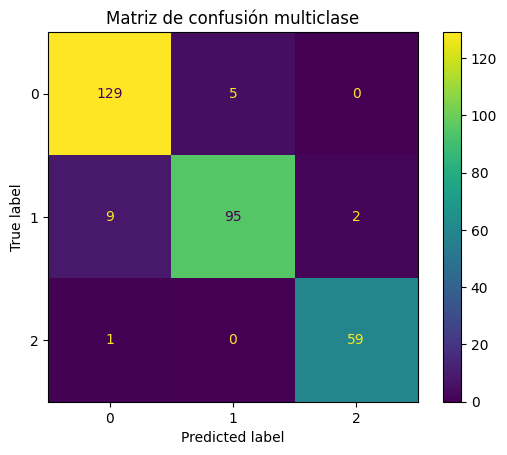

In [22]:
ConfusionMatrixDisplay(
    confusion_matrix=multiclass_confusion,
    display_labels=multiclass_model.classes_,
).plot()

plt.title("Matriz de confusión multiclase")
plt.show()


## 15. Reporte de clasificación

In [23]:
print(
    classification_report(
        y_test_multi,
        multiclass_predictions,
        digits=4,
    )
)


              precision    recall  f1-score   support

           0     0.9281    0.9627    0.9451       134
           1     0.9500    0.8962    0.9223       106
           2     0.9672    0.9833    0.9752        60

    accuracy                         0.9433       300
   macro avg     0.9484    0.9474    0.9475       300
weighted avg     0.9436    0.9433    0.9431       300



## 16. Macro, micro y weighted

### Macro

Calcula la métrica por clase y después promedia dando el mismo peso a cada clase.

### Weighted

Promedia por clase ponderando según el número de observaciones.

### Micro

Agrega todas las decisiones antes de calcular la métrica.

En clasificación multiclase de una sola etiqueta, micro precision, micro recall y micro F1 coinciden con accuracy.

In [24]:
multiclass_metrics = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro",
        "Precision weighted",
        "Recall weighted",
        "F1 weighted",
        "F1 micro",
        "Log Loss",
    ],
    "Valor": [
        accuracy_score(
            y_test_multi,
            multiclass_predictions,
        ),
        precision_score(
            y_test_multi,
            multiclass_predictions,
            average="macro",
        ),
        recall_score(
            y_test_multi,
            multiclass_predictions,
            average="macro",
        ),
        f1_score(
            y_test_multi,
            multiclass_predictions,
            average="macro",
        ),
        precision_score(
            y_test_multi,
            multiclass_predictions,
            average="weighted",
        ),
        recall_score(
            y_test_multi,
            multiclass_predictions,
            average="weighted",
        ),
        f1_score(
            y_test_multi,
            multiclass_predictions,
            average="weighted",
        ),
        f1_score(
            y_test_multi,
            multiclass_predictions,
            average="micro",
        ),
        log_loss(
            y_test_multi,
            multiclass_probabilities,
        ),
    ],
})

multiclass_metrics


,Métrica,Valor
0,Accuracy,0.9433
1,Precision macro,0.9484
2,Recall macro,0.9474
3,F1 macro,0.9475
4,Precision weighted,0.9436
5,Recall weighted,0.9433
6,F1 weighted,0.9431
7,F1 micro,0.9433
8,Log Loss,0.1878


Cuando las clases están desbalanceadas:

- macro revela el desempeño promedio tratando a todas por igual;
- weighted puede estar dominado por las clases grandes.

## 17. ROC-AUC multiclase

In [25]:
multiclass_auc_macro = roc_auc_score(
    y_test_multi,
    multiclass_probabilities,
    multi_class="ovr",
    average="macro",
)

multiclass_auc_weighted = roc_auc_score(
    y_test_multi,
    multiclass_probabilities,
    multi_class="ovr",
    average="weighted",
)

pd.DataFrame({
    "Métrica": [
        "ROC-AUC OVR macro",
        "ROC-AUC OVR weighted",
    ],
    "Valor": [
        multiclass_auc_macro,
        multiclass_auc_weighted,
    ],
})


,Métrica,Valor
0,ROC-AUC OVR macro,0.9854
1,ROC-AUC OVR weighted,0.9849


One-vs-Rest evalúa cada clase contra el conjunto formado por las demás clases.

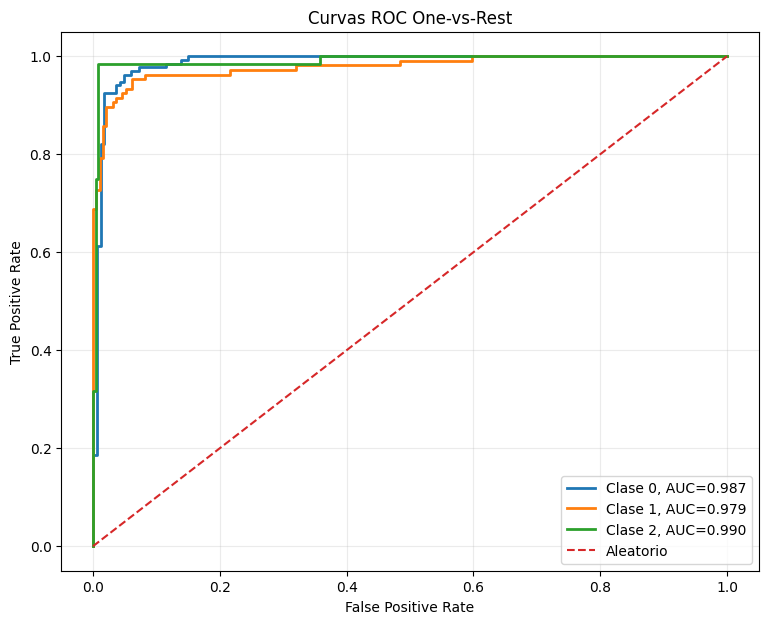

In [26]:
classes = multiclass_model.classes_

y_test_binarized = label_binarize(
    y_test_multi,
    classes=classes,
)

plt.figure(figsize=(9, 7))

for class_index, class_value in enumerate(classes):
    fpr_class, tpr_class, _ = roc_curve(
        y_test_binarized[:, class_index],
        multiclass_probabilities[:, class_index],
    )

    auc_class = roc_auc_score(
        y_test_binarized[:, class_index],
        multiclass_probabilities[:, class_index],
    )

    plt.plot(
        fpr_class,
        tpr_class,
        linewidth=2,
        label=f"Clase {class_value}, AUC={auc_class:.3f}",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Aleatorio",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC One-vs-Rest")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 18. Métricas por clase

La evaluación agregada debe complementarse con métricas específicas de cada clase.

In [27]:
report_dictionary = classification_report(
    y_test_multi,
    multiclass_predictions,
    output_dict=True,
)

report_table = (
    pd.DataFrame(report_dictionary)
    .T
)

report_table


,precision,recall,f1-score,support
0,0.9281,0.9627,0.9451,134.0000
1,0.9500,0.8962,0.9223,106.0000
2,0.9672,0.9833,0.9752,60.0000
accuracy,0.9433,0.9433,0.9433,0.9433
macro avg,0.9484,0.9474,0.9475,300.0000
weighted avg,0.9436,0.9433,0.9431,300.0000


Una clase minoritaria puede tener desempeño deficiente incluso cuando accuracy y weighted F1 son elevados.

## 19. Inspección de errores

Analizaremos las observaciones clasificadas incorrectamente y el nivel de confianza del modelo.

In [28]:
error_table = X_test_multi.copy()
error_table["Clase real"] = y_test_multi.to_numpy()
error_table["Clase predicha"] = multiclass_predictions
error_table["Probabilidad máxima"] = (
    multiclass_probabilities.max(axis=1)
)
error_table["Correcta"] = (
    error_table["Clase real"]
    == error_table["Clase predicha"]
)

error_table.loc[
    ~error_table["Correcta"]
].sort_values(
    "Probabilidad máxima",
    ascending=False,
).head(15)


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,Clase real,Clase predicha,Probabilidad máxima,Correcta
690,-3.0828,-4.7587,-0.3507,-1.9396,-1.5138,1.4829,-4.1938,1.9127,2,0,0.9867,False
1036,-0.5430,-2.1750,-1.1301,-1.2200,0.1950,-1.2616,-2.0614,-1.3125,1,2,0.9664,False
330,-1.3405,0.7017,4.3005,-2.0504,-1.0777,0.7110,-1.5008,0.9418,1,0,0.9488,False
610,-0.8007,-1.7104,0.2560,-2.0093,-1.1013,-2.2832,-2.2674,-0.9732,1,2,0.8951,False
216,-1.6815,-1.9939,-0.1331,-1.2051,0.1934,1.4142,-3.5938,0.5766,1,0,0.8950,False
70,-0.0163,1.1077,3.9552,0.4609,-0.6673,2.1950,2.2105,-1.4025,0,1,0.8693,False
439,0.4336,0.5197,2.7632,-1.5439,-1.1239,0.9745,2.2041,0.0564,0,1,0.8445,False
101,0.5620,1.4514,3.2443,-2.4854,-0.8977,0.0904,2.0387,1.3733,0,1,0.7352,False
365,-0.9954,-2.6337,1.3920,-1.6613,-1.4588,1.6061,-0.1366,-0.5057,1,0,0.7350,False
759,-0.7823,-0.0963,2.6729,-1.4480,-0.6974,-0.1344,0.0653,0.8960,1,0,0.7185,False


Errores con alta confianza merecen atención especial porque pueden indicar:

- regiones sistemáticamente mal modeladas;
- variables faltantes;
- observaciones atípicas;
- etiquetas incorrectas;
- desplazamiento de distribución.

## 20. Errores frecuentes

1. Evaluar únicamente accuracy.
2. No estratificar el split.
3. Confundir probabilidades con clases.
4. Asumir que 0.5 siempre es el umbral correcto.
5. Elegir el umbral usando test.
6. Ignorar la clase positiva relevante.
7. Interpretar ROC-AUC como accuracy.
8. Reportar promedios weighted sin revisar cada clase.
9. Suponer que una probabilidad de 0.9 está necesariamente bien calibrada.
10. Interpretar coeficientes como efectos causales.
11. Comparar modelos usando splits diferentes.
12. No comparar contra un baseline.

## 21. Experimentos sugeridos

### Experimento 1

Modifica el umbral binario y construye una regla basada en costos.

### Experimento 2

Aumenta el desbalance usando:

```python
weights=[0.95, 0.05]
```

### Experimento 3

Compara `class_weight=None` y `class_weight="balanced"`.

### Experimento 4

Cambia `class_sep` y observa el efecto sobre ROC-AUC.

### Experimento 5

Introduce más ruido mediante `flip_y`.

### Experimento 6

Compara promedios macro y weighted al hacer más pequeña una clase.

### Experimento 7

Analiza qué clases se confunden con mayor frecuencia.

### Experimento 8

Selecciona un umbral que alcance un recall mínimo de 0.80.

### Experimento 9

Compara Log Loss y accuracy entre dos modelos.

### Experimento 10

Evalúa probabilidades mediante curvas de calibración en un notebook posterior.

## 22. Resumen

En este notebook:

- ajustamos regresión logística binaria;
- obtuvimos probabilidades y clases;
- construimos matrices de confusión;
- calculamos accuracy, precision, recall y F1;
- analizamos el efecto del umbral;
- trazamos curvas ROC y Precision-Recall;
- ajustamos clasificación multiclase;
- interpretamos Softmax;
- comparamos métricas macro, micro y weighted;
- calculamos ROC-AUC One-vs-Rest;
- revisamos errores de alta confianza.

La evaluación de clasificación exige relacionar las métricas con el costo del problema y revisar el desempeño de cada clase, no únicamente un promedio global.